# LATAM Sales Profitability Analysis
### Exploratory Data Analysis | Python · Pandas · Matplotlib

## Import Libraries and Load Data

First, we import the libraries and then load the first file without specifying a header to inspect the raw structure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df_sales_data= pd.read_csv('sales_data_raw.csv')
df_sales_data.head()

,Unnamed: 0,Unnamed: 1,SKU-DON Industries Ltd.,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Page 1
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,#,Producto,Cliente,Column1,Año,Período,Ingresos,Costos,Margin,Percent
2,1,"Lobster - Baby, Boiled","Stanton, Predovic and Larson",NaN,2022,2,16,4,NaN,NaN
3,2,Tea - Herbal Orange Spice,"Stanton, Predovic and Larson",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,Cookies - Assorted,"Stanton, Predovic and Larson",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Loading

The raw dataset contains metadata in the first two rows.
The actual header starts at row 3, so we skip the first 2 rows when loading the file.

In [2]:
df_sales_data= pd.read_csv('sales_data_raw.csv', header=2, index_col='#')
df_sales_data.head()

,Producto,Cliente,Column1,Año,Período,Ingresos,Costos,Margin,Percent
#,,,,,,,,,
1,"Lobster - Baby, Boiled","Stanton, Predovic and Larson",NaN,2022.0,2.0,16.0,4.00,NaN,NaN
2,Tea - Herbal Orange Spice,"Stanton, Predovic and Larson",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Cookies - Assorted,"Stanton, Predovic and Larson",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cookies - Assorted,"Stanton, Predovic and Larson",NaN,2022.0,5.0,0.0,-7.29,NaN,NaN
5,Juice - V8 Splash,"Stanton, Predovic and Larson",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleansing

We rename the columns to English for better consistency throughout the project. Then we update the data type for Year and Period to Int64 instead of float64, as the columns contain NaN values that prevent using standard integer formatting.

In [3]:
df_sales_data.columns = ['Product', 'Client', 'Notes', 'Year', 'Period', 'Revenue', 'Costs', 'Margin', 'Percent']
df_sales_data['Year'] = df_sales_data['Year'].astype('Int64')
df_sales_data['Period'] = df_sales_data['Period'].astype('Int64')
df_sales_data.head()

,Product,Client,Notes,Year,Period,Revenue,Costs,Margin,Percent
#,,,,,,,,,
1,"Lobster - Baby, Boiled","Stanton, Predovic and Larson",NaN,2022,2,16.0,4.00,NaN,NaN
2,Tea - Herbal Orange Spice,"Stanton, Predovic and Larson",NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
3,Cookies - Assorted,"Stanton, Predovic and Larson",NaN,<NA>,<NA>,NaN,NaN,NaN,NaN
4,Cookies - Assorted,"Stanton, Predovic and Larson",NaN,2022,5,0.0,-7.29,NaN,NaN
5,Juice - V8 Splash,"Stanton, Predovic and Larson",NaN,<NA>,<NA>,NaN,NaN,NaN,NaN


## Data Cleansing - Missing Values

We inspect the dataset for missing data and identify two issues: the Notes column is mostly empty and adds no value to the analysis, so it is dropped. Additionally, rows where Costs is null are removed, as they cannot contribute to the revenue and margin analysis.

In [4]:
df_sales_data.isnull().sum()

Product      95
Client       95
Notes      6985
Year       3989
Period     3989
Revenue    3894
Costs      3989
Margin     7080
Percent    7080
dtype: int64

In [5]:
len(df_sales_data)

7080

In [6]:
df_sales_data = df_sales_data.drop(columns=['Notes'])
df_sales_data.head()

,Product,Client,Year,Period,Revenue,Costs,Margin,Percent
#,,,,,,,,
1,"Lobster - Baby, Boiled","Stanton, Predovic and Larson",2022,2,16.0,4.00,NaN,NaN
2,Tea - Herbal Orange Spice,"Stanton, Predovic and Larson",<NA>,<NA>,NaN,NaN,NaN,NaN
3,Cookies - Assorted,"Stanton, Predovic and Larson",<NA>,<NA>,NaN,NaN,NaN,NaN
4,Cookies - Assorted,"Stanton, Predovic and Larson",2022,5,0.0,-7.29,NaN,NaN
5,Juice - V8 Splash,"Stanton, Predovic and Larson",<NA>,<NA>,NaN,NaN,NaN,NaN


In [7]:
df_sales_data = df_sales_data.dropna(subset=['Costs'])
df_sales_data.head()

,Product,Client,Year,Period,Revenue,Costs,Margin,Percent
#,,,,,,,,
1,"Lobster - Baby, Boiled","Stanton, Predovic and Larson",2022,2,16.0,4.00,NaN,NaN
4,Cookies - Assorted,"Stanton, Predovic and Larson",2022,5,0.0,-7.29,NaN,NaN
11,"Butter - Salted, Micro","Predovic, Pollich and Gislason",2022,1,1980.0,-1112.11,NaN,NaN
15,"Flour - Corn, Fine","Predovic, Pollich and Gislason",2022,1,3675.0,6316.24,NaN,NaN
19,Sprouts - Onion,"Predovic, Pollich and Gislason",2022,2,0.0,0.00,NaN,NaN


In [8]:
df_sales_data.isnull().sum()

Product       0
Client        0
Year          0
Period        0
Revenue       0
Costs         0
Margin     3091
Percent    3091
dtype: int64

## Import and Cleanse secondary Data

We import the secondary dataset, which contains two tables: Client/Region and Product/Product Type. We select only the relevant columns from each table and merge them into the main dataset: the first using Client as the key, and the second using Product as the key.

In [9]:
df_details= pd.read_csv('sales_details_raw.csv')
df_details.head()

,Cliente,Region,Unnamed: 2,Producto,Tipo de Producto
0,Abshire-Price,Canada,NaN,Alize Red Passion,DONANY
1,"Altenwerth, Considine and Corkery",Mexico,NaN,Apricots - Dried,QUOKAR
2,"Anderson, Raynor and Bernier",Mexico,NaN,"Arctic Char - Fresh, Whole",SALF
3,"Bernhard, Gorczany and Prosacco",Mexico,NaN,Arizona - Plum Green Tea,QUOKAR
4,"Blick, Hudson and Monahan",Chile,NaN,Artichokes - Jerusalem,DONANY


In [10]:
df_details.columns=['Client','Region','Unnamed','Product','Product Type']
df_details.head()

,Client,Region,Unnamed,Product,Product Type
0,Abshire-Price,Canada,NaN,Alize Red Passion,DONANY
1,"Altenwerth, Considine and Corkery",Mexico,NaN,Apricots - Dried,QUOKAR
2,"Anderson, Raynor and Bernier",Mexico,NaN,"Arctic Char - Fresh, Whole",SALF
3,"Bernhard, Gorczany and Prosacco",Mexico,NaN,Arizona - Plum Green Tea,QUOKAR
4,"Blick, Hudson and Monahan",Chile,NaN,Artichokes - Jerusalem,DONANY


In [11]:
df_details_client = df_details[['Client', 'Region']]
df_details_product= df_details[['Product','Product Type']]

In [12]:
df_merged = pd.merge(df_sales_data, df_details_product, on='Product', how='left')
df_merged = pd.merge(df_merged, df_details_client, on='Client', how='left')
df_merged = df_merged[['Client', 'Region', 'Product', 'Product Type', 'Year', 'Period', 'Revenue', 'Costs', 'Margin', 'Percent']]
df_merged.head()

,Client,Region,Product,Product Type,Year,Period,Revenue,Costs,Margin,Percent
0,"Stanton, Predovic and Larson",Argentina,"Lobster - Baby, Boiled",GAMBO,2022,2,16.0,4.00,NaN,NaN
1,"Stanton, Predovic and Larson",Argentina,Cookies - Assorted,SALF,2022,5,0.0,-7.29,NaN,NaN
2,"Predovic, Pollich and Gislason",Canada,"Butter - Salted, Micro",DONANY,2022,1,1980.0,-1112.11,NaN,NaN
3,"Predovic, Pollich and Gislason",Canada,"Flour - Corn, Fine",GAMBO,2022,1,3675.0,6316.24,NaN,NaN
4,"Predovic, Pollich and Gislason",Canada,Sprouts - Onion,LAX,2022,2,0.0,0.00,NaN,NaN


In [13]:
df_merged.isnull().sum()

Client             0
Region             0
Product            0
Product Type       0
Year               0
Period             0
Revenue            0
Costs              0
Margin          3091
Percent         3091
dtype: int64

## Margin and Percent Calculation

We calculate the Margin column as the difference between Revenue and Costs, 
and the Percent column as the margin expressed as a percentage of Revenue. 
Rows where Revenue is zero produce inf or NaN values, which are replaced by 0 
to maintain data integrity for aggregated analysis.

In [14]:
df_merged['Margin'] = df_merged['Revenue'] - df_merged['Costs']
df_merged['Percent'] = round((df_merged['Margin'] / df_merged['Revenue']) * 100, 2)
df_merged['Percent'] = df_merged['Percent'].replace([float('inf'), float('-inf')], 0)
df_merged['Percent'] = df_merged['Percent'].fillna(0)
df_merged.head(10)

,Client,Region,Product,Product Type,Year,Period,Revenue,Costs,Margin,Percent
0,"Stanton, Predovic and Larson",Argentina,"Lobster - Baby, Boiled",GAMBO,2022,2,16.0,4.00,12.00,75.00
1,"Stanton, Predovic and Larson",Argentina,Cookies - Assorted,SALF,2022,5,0.0,-7.29,7.29,0.00
2,"Predovic, Pollich and Gislason",Canada,"Butter - Salted, Micro",DONANY,2022,1,1980.0,-1112.11,3092.11,156.17
3,"Predovic, Pollich and Gislason",Canada,"Flour - Corn, Fine",GAMBO,2022,1,3675.0,6316.24,-2641.24,-71.87
4,"Predovic, Pollich and Gislason",Canada,Sprouts - Onion,LAX,2022,2,0.0,0.00,0.00,0.00
5,"Willms, Predovic and Rippin",Colombia,Octopus,DONANY,2022,1,37.0,4.11,32.89,88.89
6,"Willms, Predovic and Rippin",Colombia,Veal - Ground,DAWNE,2022,2,22.5,6.03,16.47,73.20
7,"Willms, Predovic and Rippin",Colombia,Veal - Ground,DAWNE,2022,4,45.0,11.52,33.48,74.40
8,"Willms, Predovic and Rippin",Colombia,Veal - Ground,DAWNE,2022,5,67.5,17.49,50.01,74.09
9,"Willms, Predovic and Rippin",Colombia,Veal - Ground,DAWNE,2022,6,22.5,5.91,16.59,73.73


## Revenue Report

Displaying of barcharts to visualize Revenue by Region, Revenue by Product Type and Revenue by Period.

In [15]:
df_rby_region = df_merged.groupby('Region').agg(
    Revenue=('Revenue', 'sum')
)
df_rby_region.sort_values('Revenue', ascending=False).head(6)

,Revenue
Region,
Chile,449784.71
Canada,409271.80
Peru,345058.50
Mexico,224369.17
Colombia,181243.52
Argentina,175551.85


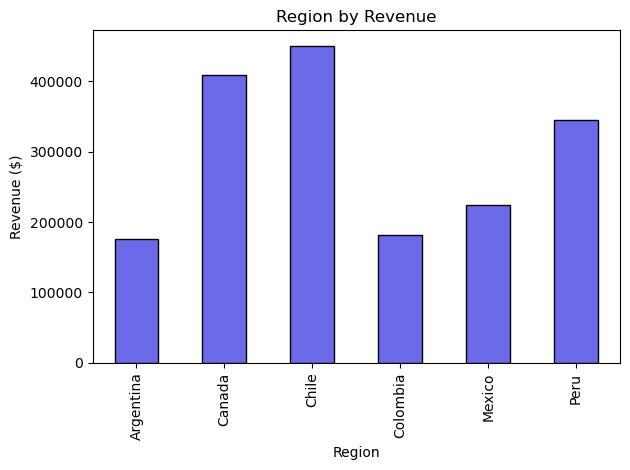

In [28]:
df_rby_region.plot(kind='bar', color='#6B6BE9', edgecolor='black')
plt.title('Region by Revenue')
plt.xlabel('Region')
plt.ylabel('Revenue ($)')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [17]:
df_rby_prodtype = df_merged.groupby('Product Type').agg(
    Revenue=('Revenue', 'sum')
)
df_rby_prodtype.sort_values('Revenue', ascending=False).head()

,Revenue
Product Type,
QUOKAR,358054.96
CHOTUS,277661.77
DONANY,230820.50
LAX,205807.03
GAMBO,198396.03


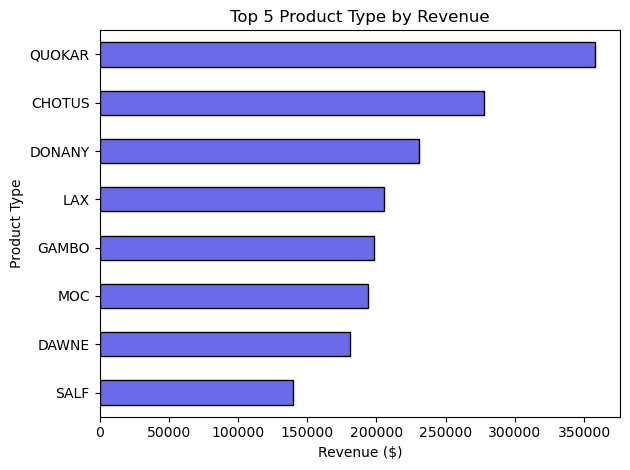

In [18]:
df_rby_prodtype.sort_values('Revenue', ascending=True).plot(kind='barh', color='#6B6BE9', edgecolor='black')
plt.title('Top 5 Product Type by Revenue')
plt.xlabel('Revenue ($)')
plt.ylabel('Product Type')
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

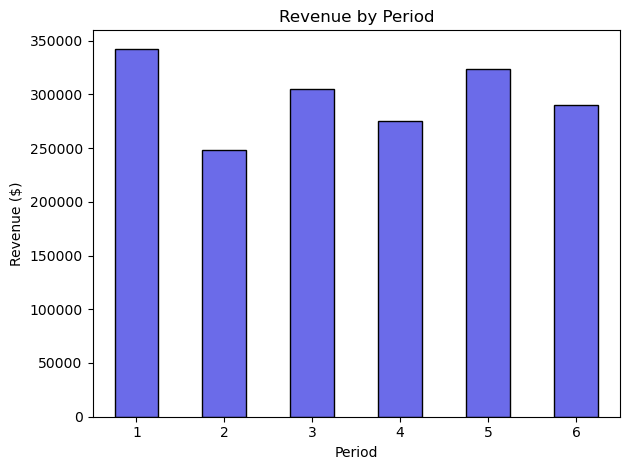

In [19]:
df_rby_period = df_merged.groupby('Period').agg(
    Revenue=('Revenue', 'sum')
)
df_rby_period.sort_values('Revenue', ascending=False).head(5)
df_rby_period = df_merged.groupby('Period')['Revenue'].sum()
df_rby_period.plot(kind='bar', color='#6B6BE9', edgecolor='black')
plt.title('Revenue by Period')
plt.xlabel('Period')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Margin Report

Displaying of barcharts to visualize Margin by Client, Margin by Region and Margin by Period.

In [20]:
df_by_client = df_merged.groupby('Client').agg(
    Revenue=('Revenue', 'sum'),
    Costs=('Costs', 'sum'),
    Margin=('Margin', 'sum')
)
df_by_client['Percent'] = round((df_by_client['Margin'] / df_by_client['Revenue']) * 100, 2)
df_by_client.sort_values('Margin', ascending=False).head(5)

,Revenue,Costs,Margin,Percent
Client,,,,
Breitenberg-Mosciski,268565.80,123862.56,144703.24,53.88
Jones & Sons,353024.03,247710.53,105313.50,29.83
Monahan-Tromp,218826.78,134453.94,84372.84,38.56
Emmerich LLC,102995.76,54202.85,48792.91,47.37
Davis-Roob,80292.55,44871.42,35421.13,44.12


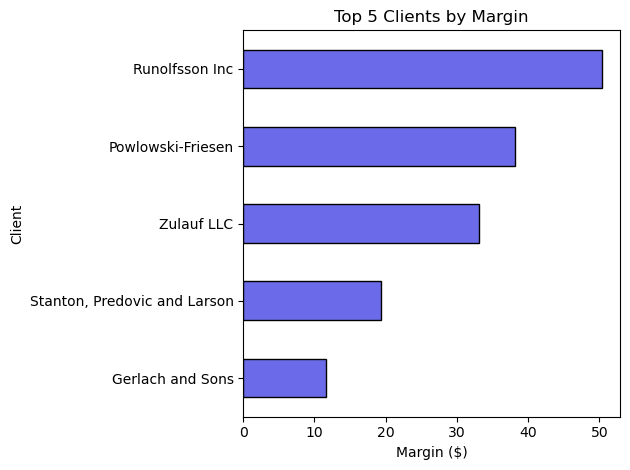

In [25]:
df_by_client = df_merged.groupby('Client')['Margin'].sum().sort_values(ascending=True).head(5)

df_by_client.plot(kind='barh', color='#6B6BE9', edgecolor='black')
plt.title('Top 5 Clients by Margin')
plt.xlabel('Margin ($)')
plt.ylabel('Client')
plt.tight_layout()
plt.show()

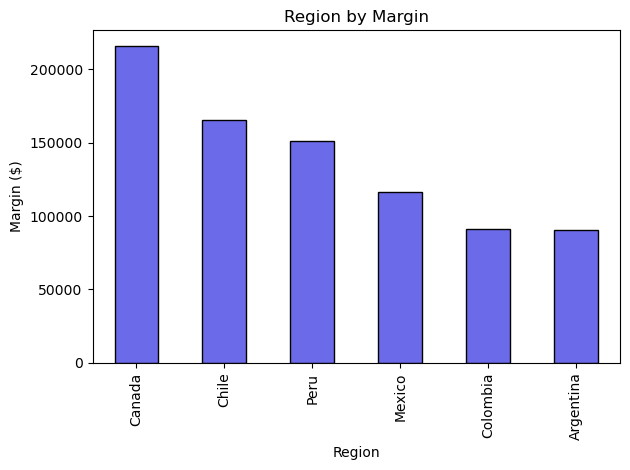

In [27]:
df_by_region = df_merged.groupby('Region').agg(
    Margin=('Margin', 'sum')
)

df_by_region.sort_values('Margin', ascending=False).head(6)

df_by_region = df_merged.groupby('Region')['Margin'].sum().sort_values(ascending=False).head(6)

df_by_region.plot(kind='bar', color='#6B6BE9', edgecolor='black')
plt.title('Region by Margin')
plt.xlabel('Region')
plt.ylabel('Margin ($)')
plt.tight_layout()
plt.show()

In [23]:
df_margin_client_region = df_merged.groupby(['Region', 'Client']).agg(
    Margin=('Margin', 'sum')
).reset_index()
df_margin_client_region.sort_values(['Region', 'Margin'], ascending=[True, True])
df_top3_region = df_margin_client_region.groupby('Region').apply(
    lambda x: x.nlargest(3, 'Margin'), include_groups=False
).reset_index(level=0).reset_index(drop=True)

df_top3_region

,Region,Client,Margin
0,Argentina,"Stokes, Lind and Jacobs",35324.94
1,Argentina,Hammes and Sons,24426.59
2,Argentina,"Daugherty, Jenkins and Moore",9594.55
3,Canada,Breitenberg-Mosciski,144703.24
4,Canada,Herzog-Gusikowski,23545.38
5,Canada,McLaughlin-Gleichner,12322.79
6,Chile,Jones & Sons,105313.50
7,Chile,"Blick, Hudson and Monahan",21390.10
8,Chile,Boyle Group,12019.42
9,Colombia,Davis-Roob,35421.13


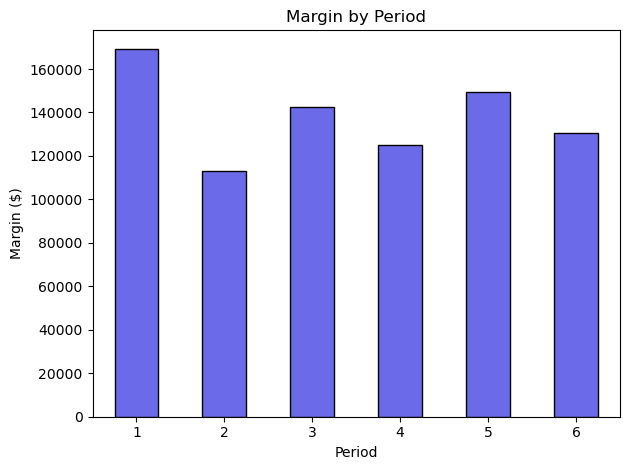

In [29]:
df_by_period = df_merged.groupby('Period').agg(
    Margin=('Margin', 'sum')
)
df_by_period.sort_values('Margin', ascending=False).head()

df_by_period = df_merged.groupby('Period')['Margin'].sum()

df_by_period.plot(kind='bar', color='#6B6BE9', edgecolor='black')
plt.title('Margin by Period')
plt.xlabel('Period')
plt.ylabel('Margin ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()